<a href="https://colab.research.google.com/github/Innotech-Manipal-TP26/Ananyaraj2ndYear/blob/main/Week5/DLNLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [94]:
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from collections import Counter
import re
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

In [95]:
dataset = load_dataset("imdb")

train_data = dataset["train"]

texts = list(train_data["text"])
labels = list(train_data["label"])

test_data = dataset["test"]
X_test = list(test_data["text"])
y_test = list(test_data["label"])

In [96]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [97]:
X_train, X_val, y_train, y_val = train_test_split(
    texts, labels,
    test_size=0.1,
    random_state=42,
    stratify=labels
)

In [98]:
def tokenize(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text.split()

In [99]:
MAX_VOCAB = 20000
UNK = "<UNK>"
PAD = "<PAD>"

counter = Counter()

for text in X_train:
    counter.update(tokenize(text))

most_common = counter.most_common(MAX_VOCAB - 2)

word2idx = {PAD: 0, UNK: 1}

for i, (word, _) in enumerate(most_common, start=2):
    word2idx[word] = i

vocab_size = len(word2idx)

In [100]:
def encode(text):
    return [word2idx.get(w, 1) for w in tokenize(text)]

In [101]:
class IMDBDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        idx = int(idx)  # 🔥 FIX

        x = torch.tensor(encode(self.texts[idx]), dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.float)

        return x, y

In [102]:
def collate_fn(batch):
    texts, labels = zip(*batch)

    lengths = torch.tensor([len(t) for t in texts], dtype=torch.long)

    padded = pad_sequence(
        texts,
        batch_first=True,
        padding_value=word2idx[PAD]
    )

    labels = torch.tensor(labels, dtype=torch.float)

    return padded, lengths, labels

In [103]:
train_ds = IMDBDataset(X_train, y_train)
val_ds = IMDBDataset(X_val, y_val)
test_ds = IMDBDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, collate_fn=collate_fn)

In [104]:
class VanillaRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x, lengths):
        x = self.embedding(x)

        packed = torch.nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        _, hidden = self.rnn(packed)

        return self.fc(hidden.squeeze(0))

In [105]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x, lengths):
        x = self.embedding(x)

        packed = torch.nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        _, (hidden, _) = self.lstm(packed)

        return self.fc(hidden[-1])

In [106]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.BCEWithLogitsLoss()

In [107]:
def train(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for x, lengths, y in loader:

        # Move only tensors that must go to GPU
        x = x.to(device)
        y = y.to(device)
        lengths = lengths  # keep on CPU (important for many RNN utils)

        optimizer.zero_grad()

        out = model(x, lengths)

        # safer than squeeze(1)
        out = out.view(-1)

        loss = criterion(out, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [108]:
criterion = torch.nn.BCEWithLogitsLoss()

In [109]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, lengths, y in loader:
            x, lengths, y = x.to(device), lengths.to(device), y.to(device)

            out = model(x, lengths).squeeze(1)
            preds = torch.sigmoid(out) > 0.5

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

In [114]:
rnn_model = VanillaRNN(vocab_size).to(device)
lstm_model = LSTMModel(vocab_size).to(device)
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.01)

In [115]:
rnn_train_losses = []
rnn_val_acc = []

for epoch in range(10):
    loss = train(rnn_model, train_loader, optimizer, criterion, device)
    acc = evaluate(rnn_model, val_loader)

    rnn_train_losses.append(loss)
    rnn_val_acc.append(acc)

    print(f"[RNN] Epoch {epoch+1} Loss:{loss:.4f} Val Acc:{acc:.4f}")

[RNN] Epoch 1 Loss:0.7040 Val Acc:0.5040
[RNN] Epoch 2 Loss:0.7040 Val Acc:0.5040
[RNN] Epoch 3 Loss:0.7041 Val Acc:0.5040
[RNN] Epoch 4 Loss:0.7041 Val Acc:0.5040
[RNN] Epoch 5 Loss:0.7041 Val Acc:0.5040
[RNN] Epoch 6 Loss:0.7040 Val Acc:0.5040
[RNN] Epoch 7 Loss:0.7040 Val Acc:0.5040
[RNN] Epoch 8 Loss:0.7041 Val Acc:0.5040
[RNN] Epoch 9 Loss:0.7041 Val Acc:0.5040
[RNN] Epoch 10 Loss:0.7041 Val Acc:0.5040


In [116]:
lstm_train_losses = []
lstm_val_acc = []

for epoch in range(10):
    loss = train(lstm_model, train_loader, optimizer, criterion, device)
    acc = evaluate(lstm_model, val_loader)

    lstm_train_losses.append(loss)
    lstm_val_acc.append(acc)

    print(f"[LSTM] Epoch {epoch+1} Loss:{loss:.4f} Val Acc:{acc:.4f}")

[LSTM] Epoch 1 Loss:0.4583 Val Acc:0.8552
[LSTM] Epoch 2 Loss:0.2431 Val Acc:0.8644
[LSTM] Epoch 3 Loss:0.1646 Val Acc:0.8612
[LSTM] Epoch 4 Loss:0.1100 Val Acc:0.8712
[LSTM] Epoch 5 Loss:0.0742 Val Acc:0.8648
[LSTM] Epoch 6 Loss:0.0594 Val Acc:0.8720
[LSTM] Epoch 7 Loss:0.0471 Val Acc:0.8656
[LSTM] Epoch 8 Loss:0.0477 Val Acc:0.8628
[LSTM] Epoch 9 Loss:0.0434 Val Acc:0.8612
[LSTM] Epoch 10 Loss:0.0340 Val Acc:0.8540


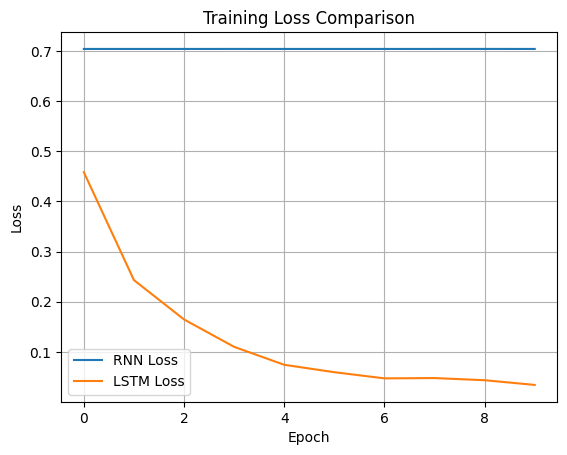

In [117]:
import matplotlib.pyplot as plt

plt.plot(rnn_train_losses, label="RNN Loss")
plt.plot(lstm_train_losses, label="LSTM Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid()
plt.show()

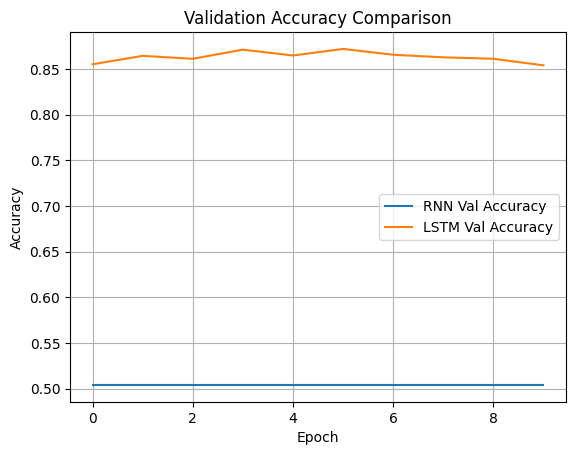

In [118]:
plt.plot(rnn_val_acc, label="RNN Val Accuracy")
plt.plot(lstm_val_acc, label="LSTM Val Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.grid()
plt.show()

In [119]:
import torch
from torch.utils.data import Dataset

class SeqDataset(Dataset):
    def __init__(self, seq_len, size=5000, vocab_size=2):
        self.seq_len = seq_len
        self.size = size
        self.vocab_size = vocab_size

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        # sequence of token indices (IMPORTANT: LONG for embedding)
        seq = torch.randint(
            0,
            self.vocab_size,
            (self.seq_len,),
            dtype=torch.long
        )

        # label: 1 if ANY token is 1, else 0
        label = torch.tensor(int((seq == 1).any()), dtype=torch.float32)

        return seq, label

In [120]:
seq_lengths = [5, 10, 20, 50, 100, 200]

In [121]:
for L in seq_lengths:
    print(f"\nTraining seq length: {L}")

    # 🔥 MUST recreate dataset per L
    train_dataset = SeqDataset(L)
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)

    # model reset per experiment
    rnn_model = VanillaRNN(vocab_size).to(device)

    optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.01)

    acc = train(rnn_model, train_loader, optimizer, criterion, device)

    print(f"[RNN] SeqLen={L} | Val Acc: {acc:.4f}")


Training seq length: 5
[RNN] SeqLen=5 | Val Acc: 0.0109

Training seq length: 10
[RNN] SeqLen=10 | Val Acc: 0.0190

Training seq length: 20
[RNN] SeqLen=20 | Val Acc: 0.0120

Training seq length: 50
[RNN] SeqLen=50 | Val Acc: 0.0105

Training seq length: 100
[RNN] SeqLen=100 | Val Acc: 0.0141

Training seq length: 200
[RNN] SeqLen=200 | Val Acc: 0.0119


In [122]:
for L in seq_lengths:
    print(f"\nTraining seq length: {L}")

    # 🔥 MUST recreate dataset per L
    train_dataset = SeqDataset(L)
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)

    # model reset per experiment
    lstm_model = LSTMModel(vocab_size).to(device)

    optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.01)

    acc = train(lstm_model, train_loader, optimizer, criterion, device)

    print(f"[RNN] SeqLen={L} | Val Acc: {acc:.4f}")


Training seq length: 5
[RNN] SeqLen=5 | Val Acc: 0.6086

Training seq length: 10
[RNN] SeqLen=10 | Val Acc: 0.6851

Training seq length: 20
[RNN] SeqLen=20 | Val Acc: 0.6520

Training seq length: 50
[RNN] SeqLen=50 | Val Acc: 0.7899

Training seq length: 100
[RNN] SeqLen=100 | Val Acc: 0.7072

Training seq length: 200
[RNN] SeqLen=200 | Val Acc: 0.6672


In [123]:
from sklearn.decomposition import PCA
import numpy as np

embeddings = lstm_model.embedding.weight.detach().cpu().numpy()

In [124]:
words = ["good", "bad", "amazing", "terrible", "boring", "excellent", "awful", "movie"]

indices = [word2idx[w] for w in words if w in word2idx]

selected = embeddings[indices]

In [125]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(selected)

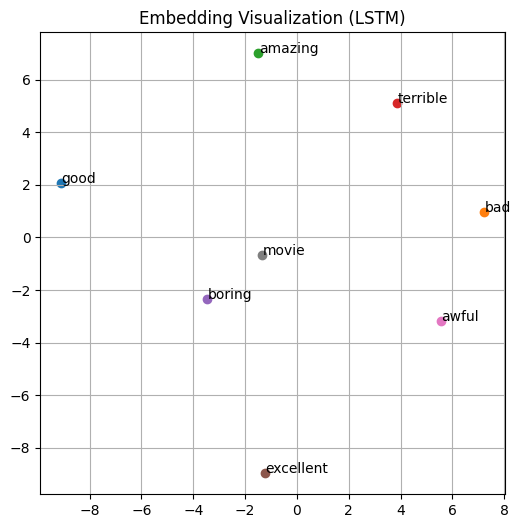

In [126]:
plt.figure(figsize=(6,6))

for i, word in enumerate(words):
    if word in word2idx:
        plt.scatter(reduced[i,0], reduced[i,1])
        plt.text(reduced[i,0]+0.01, reduced[i,1]+0.01, word)

plt.title("Embedding Visualization (LSTM)")
plt.grid()
plt.show()